In [1]:
import numpy as np
import matplotlib.pyplot as plt
import climatecritters as cc
from climatecritters.model_critters.ebm import EBM0D
from climatecritters.utils import noise as cc_noise
import pyleoclim as pyleo

T_SPAN = (0, 500)   # years


## Clean baseline

Run once; reuse throughout for comparison.

In [2]:
model_clean = EBM0D()
out_clean   = model_clean.integrate(t_span=T_SPAN, y0=[255.0], method='RK45')
T_clean     = out_clean.state_variables['T']
t_clean     = out_clean.time


## Noisy forcing

Wrap a stochastic process in a `cc.Forcing` callable and attach it with
`register_forcing`. The noise is part of the *input*, not the state equations,
so the model stays deterministic and the perturbation is inspectable.

Here: AR(1) noise added to `S0` (the solar constant).

**Always visualise the forcing before attaching it.**


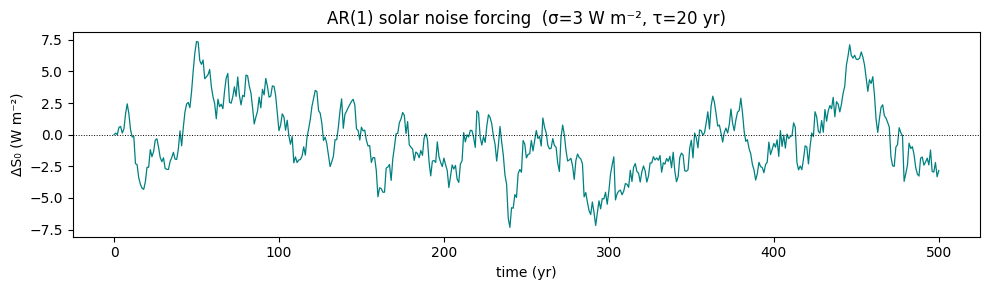

In [3]:
t_eval = np.arange(T_SPAN[0], T_SPAN[1] + 1, dtype=float)

# AR(1): σ=3 W m⁻², τ=20 yr
sigma_drive, tau_drive = 3.0, 20.0
rng_f = np.random.default_rng(0)
noise_vals = np.zeros(len(t_eval))
for i in range(1, len(noise_vals)):
    alpha = np.exp(-1.0 / tau_drive)
    noise_vals[i] = (alpha * noise_vals[i-1]
                     + sigma_drive * np.sqrt(1 - alpha**2) * rng_f.standard_normal())

solar_noise = cc.Forcing(
    lambda t, _t=t_eval, _v=noise_vals: float(np.interp(t, _t, _v))
)

# Visualise first
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t_eval, noise_vals, color='teal', lw=0.9)
ax.axhline(0, color='k', lw=0.7, ls=':')
ax.set_xlabel('time (yr)'); ax.set_ylabel('ΔS₀ (W m⁻²)')
ax.set_title('AR(1) solar noise forcing  (σ=3 W m⁻², τ=20 yr)')
plt.tight_layout(); plt.show()


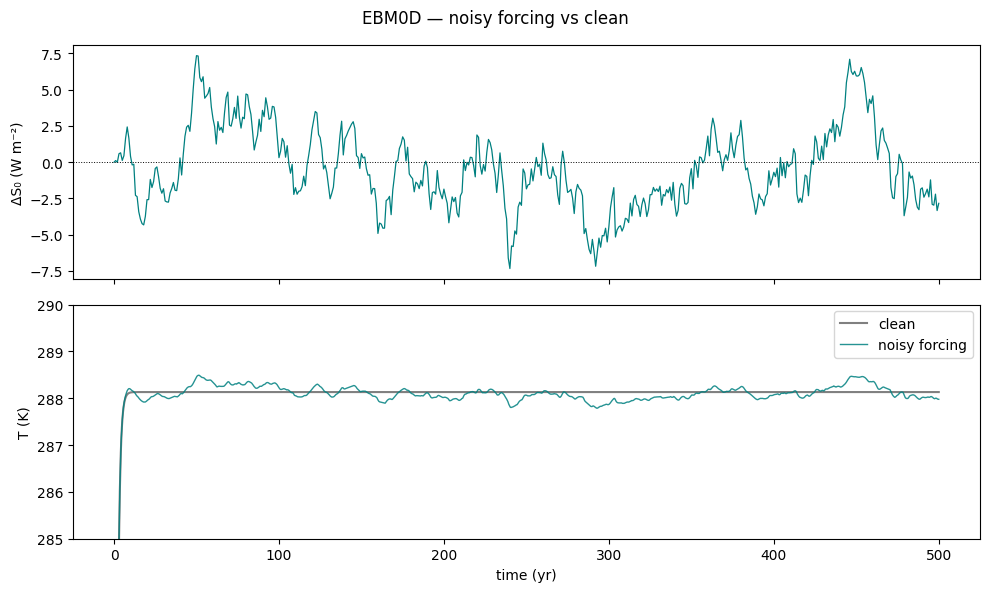

In [4]:
model_noisy_f = EBM0D()
model_noisy_f.register_forcing('S0', solar_noise, 'additive')
out_noisy_f   = model_noisy_f.integrate(t_span=T_SPAN, y0=[255.0], method='RK45')

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(t_eval, noise_vals, color='teal', lw=0.9)
axes[0].axhline(0, color='k', lw=0.7, ls=':')
axes[0].set_ylabel('ΔS₀ (W m⁻²)')

axes[1].plot(t_clean, T_clean, color='gray', lw=1.5, label='clean')
axes[1].plot(out_noisy_f.time, out_noisy_f.state_variables['T'],
             color='teal', lw=1.0, alpha=0.85, label='noisy forcing')
axes[1].set_xlabel('time (yr)'); axes[1].set_ylabel('T (K)'); axes[1].legend()
axes[1].set_ylim((285,290))
fig.suptitle('EBM0D — noisy forcing vs clean')
plt.tight_layout(); plt.show()


**Figure.** The noisy run tracks the forcing with a lag set by the thermal
inertia.  The perturbations never drive the model to a new equilibrium because
the noise is zero-mean and the heat capacity keeps the system well-damped.


## Noise during integration

SDE integrators inject noise at every timestep: $dT = f(T)\,dt + \sigma\,dW$.

To use them:
1. Set `model.sde_noise = lambda t, state: noise_scale_vector`
2. Call `integrate(..., method='euler_maruyama')` — or `heun_maruyama`
   (strong order 1.0) or `milstein` (strong order 1.0, multiplicative noise)
3. Pass `kwargs={'dt': ..., 'random_seed': N}` — `dt` is required

`heun_maruyama` is the default recommendation: better accuracy than
`euler_maruyama` at the same `dt`, with no extra cost for additive noise.


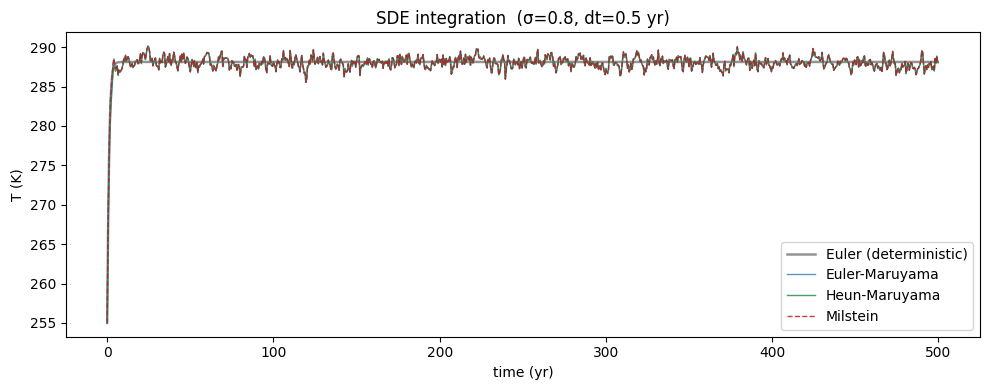

In [5]:
SIGMA_SDE = 0.8   # K yr⁻⁰·⁵
DT_SDE    = 0.5   # yr

def sde_noise_fn(t, state):
    return np.full_like(np.asarray(state, dtype=float), SIGMA_SDE)

# Deterministic Euler baseline vs three SDE methods
configs = [
    ('euler',         {},                          'gray',      '-',  'Euler (deterministic)'),
    ('euler_maruyama',{'random_seed': 0},          'steelblue', '-',  'Euler-Maruyama'),
    ('heun_maruyama', {'random_seed': 0},          'seagreen',  '-',  'Heun-Maruyama'),
    ('milstein',      {'random_seed': 0},          'firebrick', '--', 'Milstein'),
]

runs_sde = {}
for method, extra_kw, color, ls, label in configs:
    m = EBM0D()
    if method != 'euler':
        m.sde_noise = sde_noise_fn
    out = m.integrate(t_span=T_SPAN, y0=[255.0], method=method,
                      kwargs={'dt': DT_SDE, **extra_kw})
    runs_sde[label] = (out, color, ls)

fig, ax = plt.subplots(figsize=(10, 4))
for label, (out, color, ls) in runs_sde.items():
    lw = 1.8 if label == 'Euler (deterministic)' else 1.0
    ax.plot(out.time, out.state_variables['T'],
            color=color, ls=ls, lw=lw, alpha=0.85, label=label)
ax.set_xlabel('time (yr)'); ax.set_ylabel('T (K)')
ax.set_title(f'SDE integration  (σ={SIGMA_SDE}, dt={DT_SDE} yr)')
ax.legend(); plt.tight_layout(); plt.show()


**Figure.** For **additive** noise (σ independent of state) Milstein's
correction term is zero, so Heun-Maruyama and Milstein give identical
trajectories at the same seed.  All three converge to the same neighbourhood
of ~288 K — noise is zero-mean, so it doesn't shift the attractor.


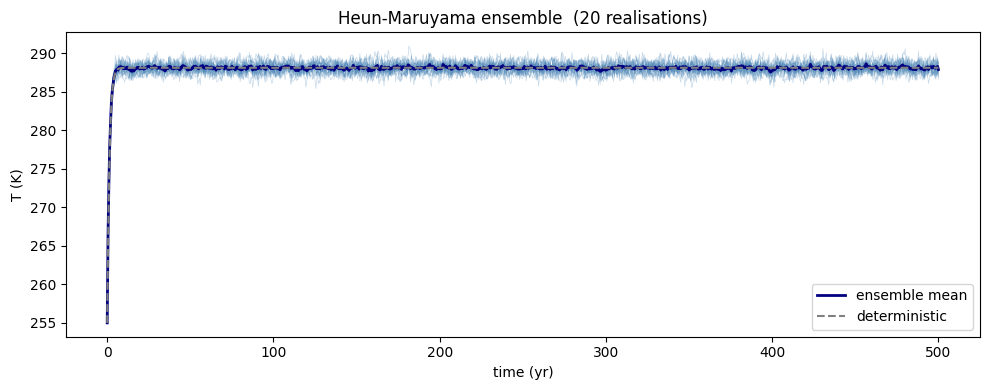

In [6]:
# Run an ensemble to characterise spread
N_ENS = 20
ens_T, ens_t = [], None
for seed in range(N_ENS):
    m = EBM0D(); m.sde_noise = sde_noise_fn
    out = m.integrate(t_span=T_SPAN, y0=[255.0], method='heun_maruyama',
                      kwargs={'dt': DT_SDE, 'random_seed': seed})
    ens_T.append(out.state_variables['T'])
    if ens_t is None:
        ens_t = out.time          # time axis from the SDE runs
ens_arr = np.array(ens_T)

# Trim the clean reference to the same length if needed
T_clean_ref = T_clean[:len(ens_t)] if len(T_clean) > len(ens_t) else T_clean
t_clean_ref = t_clean[:len(ens_t)] if len(t_clean) > len(ens_t) else t_clean

fig, ax = plt.subplots(figsize=(10, 4))
for row in ens_arr:
    ax.plot(ens_t, row, color='steelblue', lw=0.5, alpha=0.3)
ax.plot(ens_t, ens_arr.mean(axis=0), color='navy', lw=2, label='ensemble mean')
ax.plot(t_clean_ref, T_clean_ref, color='gray', lw=1.5, ls='--', label='deterministic')
ax.set_xlabel('time (yr)'); ax.set_ylabel('T (K)')
ax.set_title(f'Heun-Maruyama ensemble  ({N_ENS} realisations)')
ax.legend(); plt.tight_layout(); plt.show()


**Figure.** Ensemble mean converges to the deterministic equilibrium; spread
is largest during the fast transient when the gradient is steepest.


## Noise post-integration

Run the model cleanly, then add noise to the output series with
`climatecritters.utils.noise`.  Use this when the noise represents *observation
error* or *proxy noise* rather than intrinsic variability — the dynamics stay
deterministic and reproducible.


Time axis values sorted in ascending order


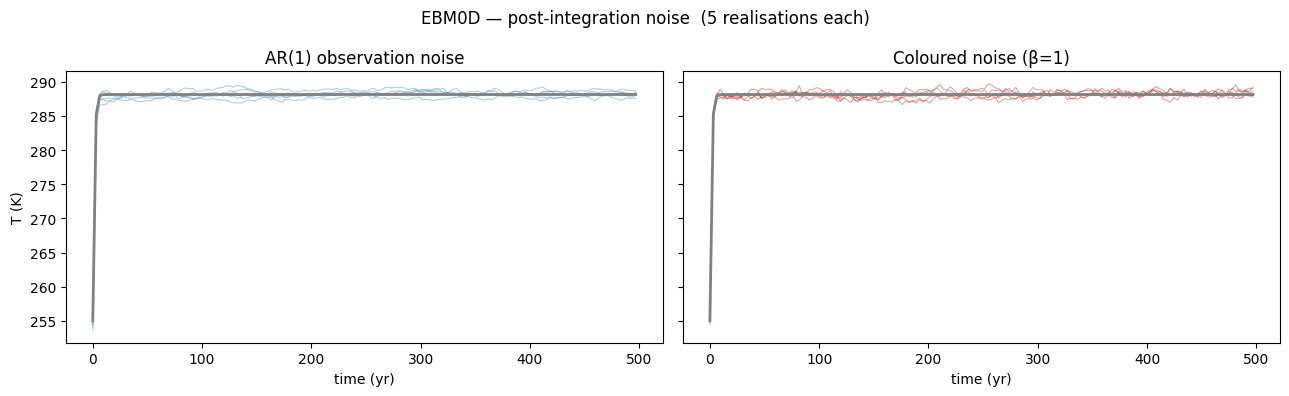

{'label': 'deterministic'}
{'label': 'deterministic'}
{'label': 'Power-law surrogates ($S(f) \\propto f^{-\\beta}$) #5'}


In [7]:
ts_clean = pyleo.Series(time=t_clean, value=T_clean,
                        time_name='time', time_unit='yr',
                        value_name='T', value_unit='K', label='deterministic')

# RK45 produces irregular timesteps — interpolate to regular grid before
# generating surrogates (ar1sim requires evenly-spaced time)
ts_clean_reg = ts_clean.interp()
t_reg = ts_clean_reg.time
T_reg = ts_clean_reg.value

# AR(1) surrogates matched to the signal's autocorrelation
surr_ar1 = cc_noise.from_series(ts_clean_reg, method='ar1sim', number=5, seed=1)

# Pink noise (β=1) from parameters
surr_cn = cc_noise.from_param(method='CN', noise_param=[1], length=len(t_reg),
                               time_pattern='specified',
                               settings={'time': t_reg}, number=5, seed=2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, surr, color, title in [
        (axes[0], surr_ar1, 'steelblue', 'AR(1) observation noise'),
        (axes[1], surr_cn,  'firebrick', 'Coloured noise (β=1)'),
]:
    ax.plot(t_reg, T_reg, color='gray', lw=2, label='deterministic', zorder=3)
    for s in surr.series_list:
        noisy = T_reg + 0.5 * (s.value - s.value.mean()) / s.value.std()
        ax.plot(t_reg, noisy, color=color, lw=0.7, alpha=0.45)
    ax.set_xlabel('time (yr)'); ax.set_title(title)
axes[0].set_ylabel('T (K)')
fig.suptitle('EBM0D — post-integration noise  (5 realisations each)')
plt.tight_layout()


**Figure.** Both panels converge to exactly the same deterministic equilibrium —
post-integration noise does not feed back into dynamics.  AR(1) produces slower
meanders; pink noise adds spectral richness across all scales.


## Which approach to use?

| | Noisy forcing | Noise during integration | Noise post-integration |
|---|---|---|---|
| **Feeds back into dynamics** | ✓ (through input) | ✓ (on state) | ✗ |
| **Deterministic model preserved** | ✓ | ✗ | ✓ |
| **Physical interpretation** | Boundary/external forcing | Intrinsic variability | Measurement / proxy noise |
| **Reproducibility** | Pre-draw + wrap | `random_seed` kwarg | `seed` in `from_series`/`from_param` |
| **Requires SDE integrator** | ✗ | ✓ | ✗ |
